In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [2]:
base_version = pd.read_csv('/kaggle/input/bank-account-fraud-dataset-neurips-2022/Base.csv')

## **Dataset Column Analysis** #

| Column Name | Description |
|-------------|-------------|
| fraud_bool | Fraud label (1 if fraud, 0 if legit) |
| income | Annual income of the applicant in quantiles |
| name_email_similarity | Metric of similarity between email and applicant's name |
| prev_address_months_count | Number of months in previous registered address |
| current_address_months_count | Months in currently registered address |
| customer_age | Applicant's age in bins per decade |
| days_since_request | Number of days passed since application was done |
| intended_balcon_amount | Initial transferred amount for application |
| payment_type | Credit payment plan type |
| zip_count_4w | Number of applications within same zip code in last 4 weeks |
| velocity_6h | Velocity of total applications made in last 6 hours |
| velocity_24h | Velocity of total applications made in last 24 hours |
| velocity_4w | Velocity of total applications made in last 4 weeks |
| bank_branch_count_8w | Number of total applications in selected bank branch in last 8 weeks |
| date_of_birth_distinct_emails_4w | Number of emails for applicants with same date of birth in last 4 weeks |
| employment_status | Employment status of the applicant |
| credit_risk_score | Internal score of application risk |
| email_is_free | Domain of application email (either free or paid) |
| housing_status | Current residential status for applicant |
| phone_home_valid | Validity of provided home phone |
| phone_mobile_valid | Validity of provided mobile phone |
| bank_months_count | How old is previous account in months |
| has_other_cards | If applicant has other cards from the same banking company |
| proposed_credit_limit | Applicant's proposed credit limit |
| foreign_request | If origin country of request is different from bank's country |
| source | Online source of application |
| session_length_in_minutes | Length of user session in banking website in minutes |
| device_os | Operative system of device that made request |
| keep_alive_session | User option on session logout |
| device_distinct_emails_8w | Number of distinct emails in banking website from used device in last 8 weeks |
| device_fraud_count | Number of fraudulent applications with used device |
| month | Month where the application was made |

In [3]:
base_version.shape

(1000000, 32)

In [4]:
base_version.columns

Index(['fraud_bool', 'income', 'name_email_similarity',
       'prev_address_months_count', 'current_address_months_count',
       'customer_age', 'days_since_request', 'intended_balcon_amount',
       'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h',
       'velocity_4w', 'bank_branch_count_8w',
       'date_of_birth_distinct_emails_4w', 'employment_status',
       'credit_risk_score', 'email_is_free', 'housing_status',
       'phone_home_valid', 'phone_mobile_valid', 'bank_months_count',
       'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source',
       'session_length_in_minutes', 'device_os', 'keep_alive_session',
       'device_distinct_emails_8w', 'device_fraud_count', 'month'],
      dtype='object')

In [5]:
base_version.head(25)

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0
5,0,0.6,0.294840,-1,369,30,0.024232,-1.232556,AD,1204,...,0,200.0,0,INTERNET,6.987316,linux,1,1,0,0
6,0,0.2,0.773085,22,4,40,0.006919,-0.544676,AB,1998,...,0,200.0,0,INTERNET,28.199923,x11,1,1,0,0
7,0,0.8,0.153880,-1,103,40,0.045122,-1.101184,AB,1548,...,1,200.0,0,INTERNET,11.234264,other,1,1,0,0
8,0,0.3,0.523655,21,2,30,0.035206,-0.955737,AB,1781,...,0,200.0,0,INTERNET,5.329387,other,1,1,0,0
9,0,0.8,0.834475,-1,134,20,0.017245,-1.356393,AD,3113,...,0,1500.0,0,INTERNET,4.103970,other,1,1,0,0


In [6]:
base_version.tail()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
999995,0,0.8,0.124690,-1,143,30,0.051348,-0.826239,AB,530,...,0,1500.0,0,INTERNET,16.967770,other,0,1,0,7
999996,0,0.9,0.824544,-1,193,30,0.009591,0.008307,AC,408,...,1,1000.0,0,INTERNET,1.504109,macintosh,0,1,0,7
999997,0,0.8,0.140891,-1,202,10,0.059287,50.609995,AA,749,...,0,200.0,0,INTERNET,16.068595,other,0,1,0,7
999998,0,0.9,0.002480,52,3,30,0.023357,-1.313387,AB,707,...,0,200.0,0,INTERNET,1.378683,linux,1,1,0,7
999999,0,0.6,0.993391,-1,174,30,0.020422,14.942456,AA,655,...,1,200.0,0,INTERNET,1.947926,other,1,1,0,7


In [7]:
base_version.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [8]:
base_version.describe().T

,count,mean,std,min,25%,50%,75%,max
fraud_bool,1000000.0,0.011029,0.104438,0.000000e+00,0.000000,0.000000,0.000000,1.000000
income,1000000.0,0.562696,0.290343,1.000000e-01,0.300000,0.600000,0.800000,0.900000
name_email_similarity,1000000.0,0.493694,0.289125,1.434550e-06,0.225216,0.492153,0.755567,0.999999
prev_address_months_count,1000000.0,16.718568,44.046230,-1.000000e+00,-1.000000,-1.000000,12.000000,383.000000
current_address_months_count,1000000.0,86.587867,88.406599,-1.000000e+00,19.000000,52.000000,130.000000,428.000000
customer_age,1000000.0,33.689080,12.025799,1.000000e+01,20.000000,30.000000,40.000000,90.000000
days_since_request,1000000.0,1.025705,5.381835,4.036860e-09,0.007193,0.015176,0.026331,78.456904
intended_balcon_amount,1000000.0,8.661499,20.236155,-1.553055e+01,-1.181488,-0.830507,4.984176,112.956928
zip_count_4w,1000000.0,1572.692049,1005.374565,1.000000e+00,894.000000,1263.000000,1944.000000,6700.000000
velocity_6h,1000000.0,5665.296605,3009.380665,-1.706031e+02,3436.365848,5319.769349,7680.717827,16715.565404


In [9]:
base_version.describe(include = 'object')

,payment_type,employment_status,housing_status,source,device_os
count,1000000,1000000,1000000,1000000,1000000
unique,5,7,7,2,5
top,AB,CA,BC,INTERNET,other
freq,370554,730252,372143,992952,342728


In [10]:
base_version.drop('device_fraud_count', axis = 1, inplace = True) # The colunm only contain zero values

In [11]:
base_version[base_version == -1].count().sort_values(ascending = False).head(10)

prev_address_months_count       712920
bank_months_count               253635
current_address_months_count      4254
session_length_in_minutes         2015
credit_risk_score                  488
device_distinct_emails_8w          359
fraud_bool                           0
intended_balcon_amount               0
payment_type                         0
zip_count_4w                         0
dtype: int64

In [12]:
base_version.duplicated().sum()

0

In [13]:
base_version['fraud_bool'].value_counts()

fraud_bool
0    988971
1     11029
Name: count, dtype: int64

In [14]:
categorical_columns = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os', 'month']
binary_columns = ['email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'has_other_cards', 'foreign_request', 'keep_alive_session']
target_column = ['fraud_bool']

numerical_columns = list(
    set(base_version.columns)
    - set(categorical_columns)
    - set(binary_columns)
    - set(target_column)
)

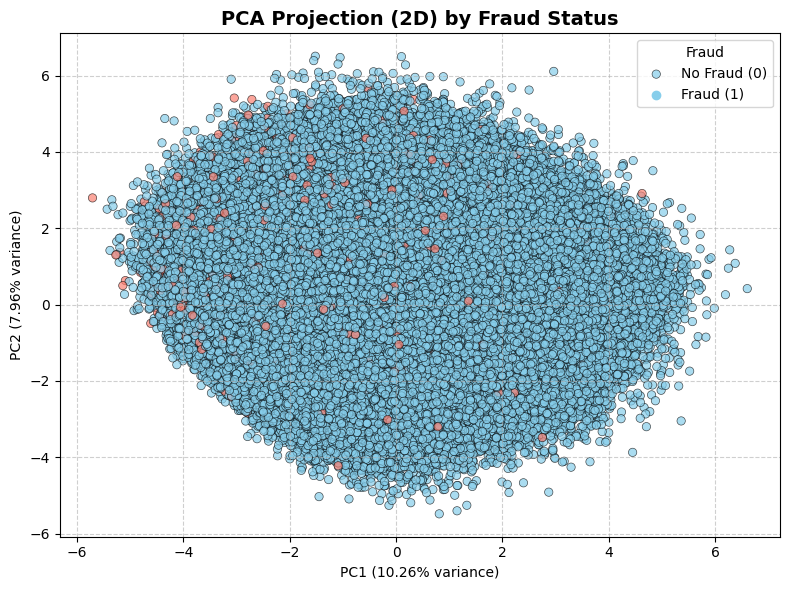

In [15]:
data = base_version[numerical_columns + binary_columns]

targets = base_version[target_column]

data = data.replace([np.inf, -np.inf], np.nan).dropna()
targets = base_version.loc[data.index, target_column]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df[target_column] = targets.values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue=target_column[0], # Changed from target_column to target_column[0]
    palette=['skyblue', 'salmon'],
    alpha=0.7,
    edgecolor='k'
)
plt.title('PCA Projection (2D) by Fraud Status', fontsize=14, weight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.legend(title='Fraud', labels=['No Fraud (0)', 'Fraud (1)'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

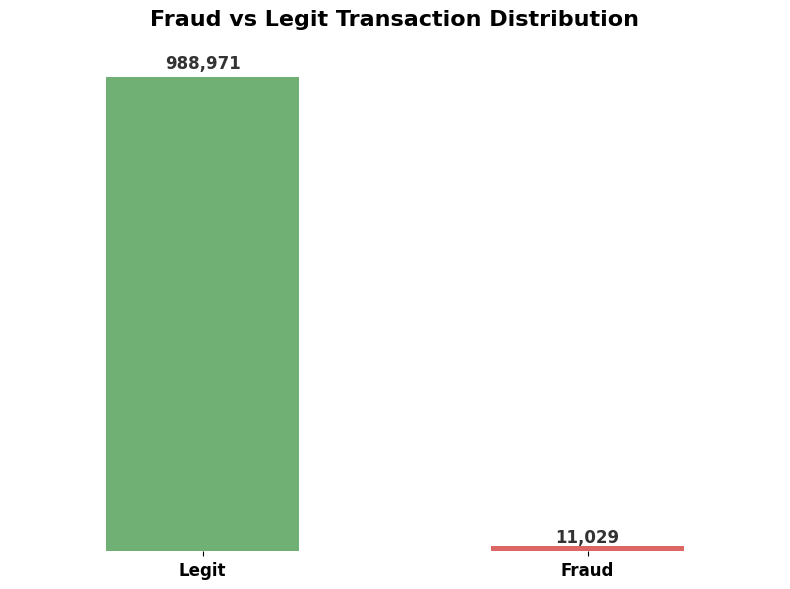

In [16]:
colors = ['#66BB6A', '#EF5350']

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=base_version, x='fraud_bool', palette=colors, width=0.5)

plt.title("Fraud vs Legit Transaction Distribution", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("")
plt.ylabel("")
plt.xticks([0, 1], ['Legit', 'Fraud'], fontsize=12, fontweight='semibold')
plt.yticks([])
sns.despine(left=True, bottom=True)

for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(
        f'{count:,}',
        (p.get_x() + p.get_width()/2., p.get_height() + (p.get_height() * 0.01)),
        ha='center', va='bottom', fontsize=12, color='#333', fontweight='semibold'
    )

plt.tight_layout()
plt.show()

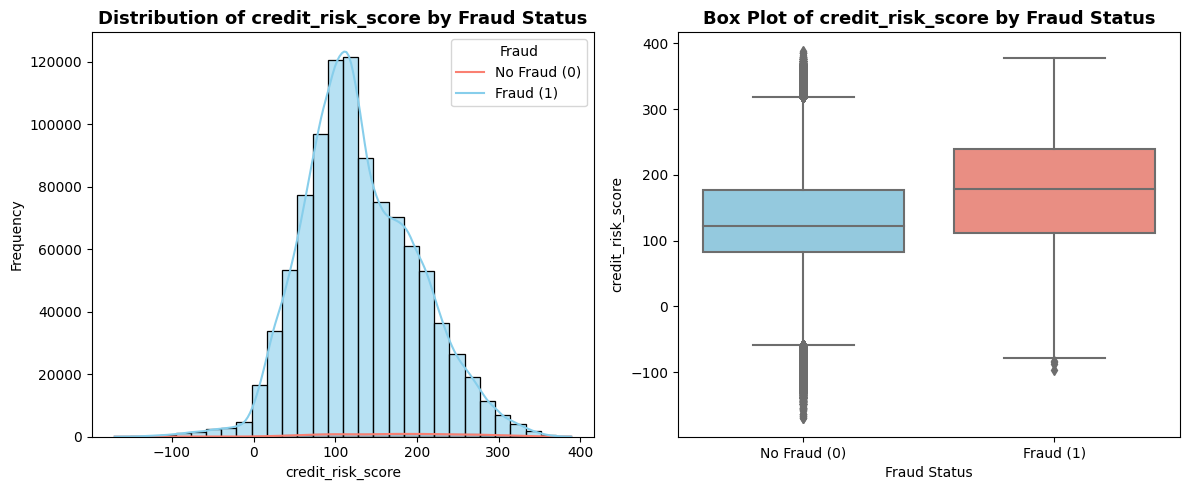

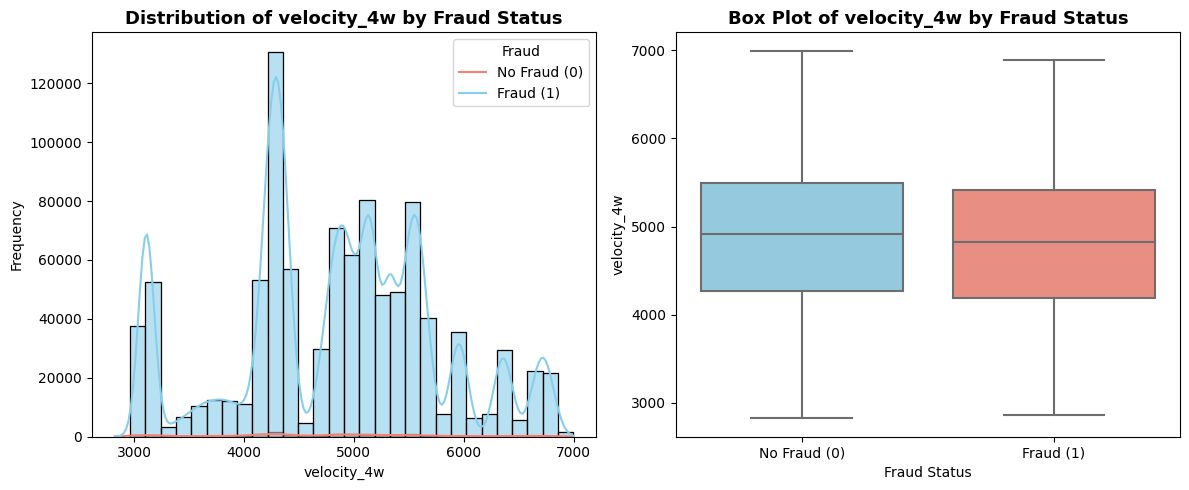

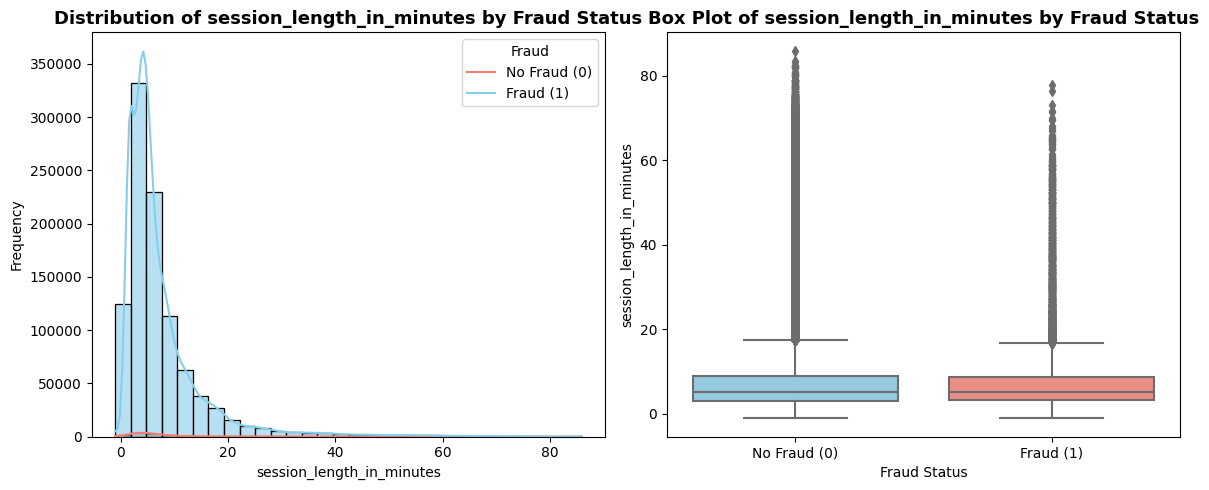

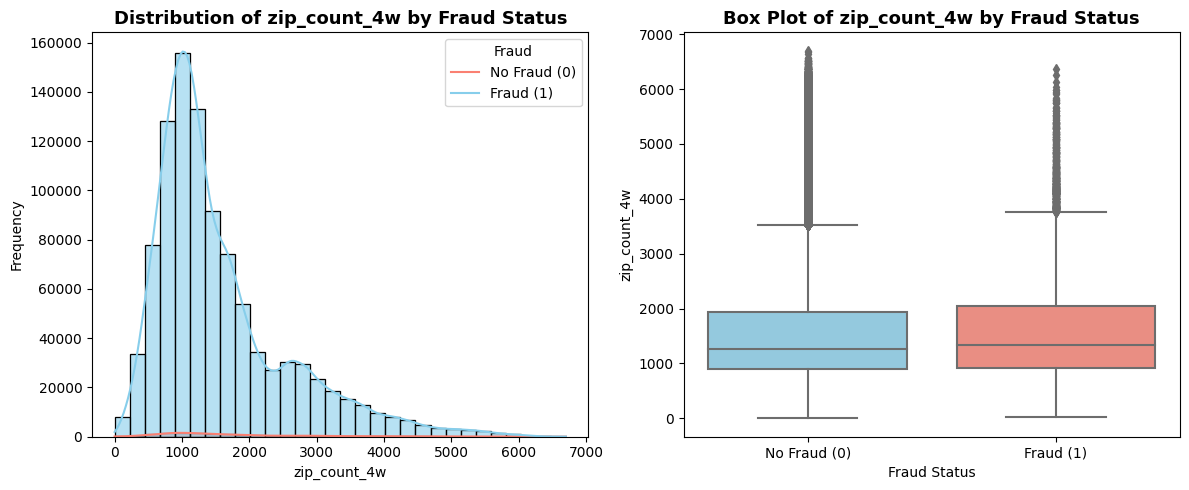

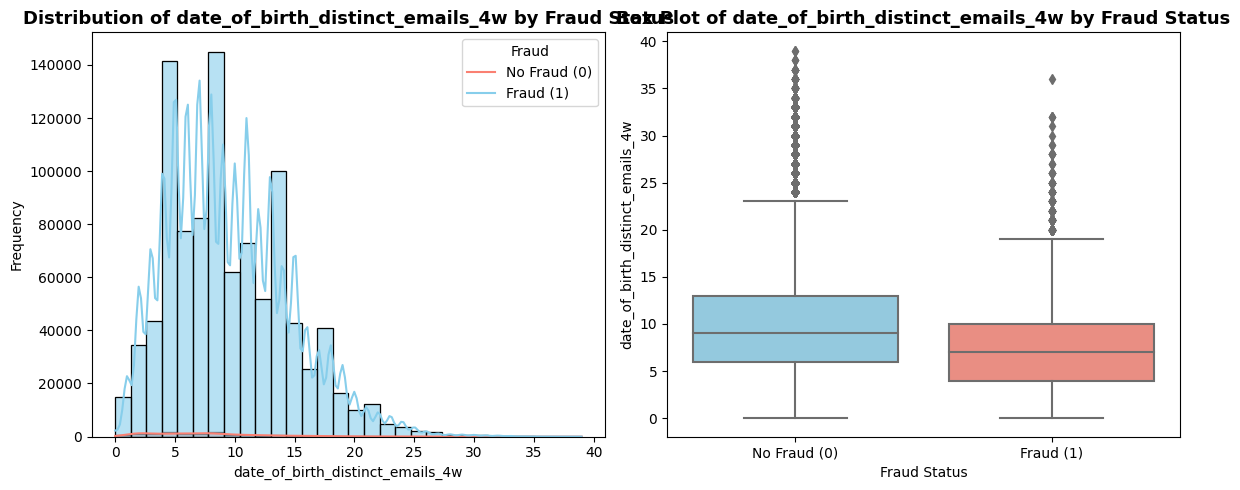

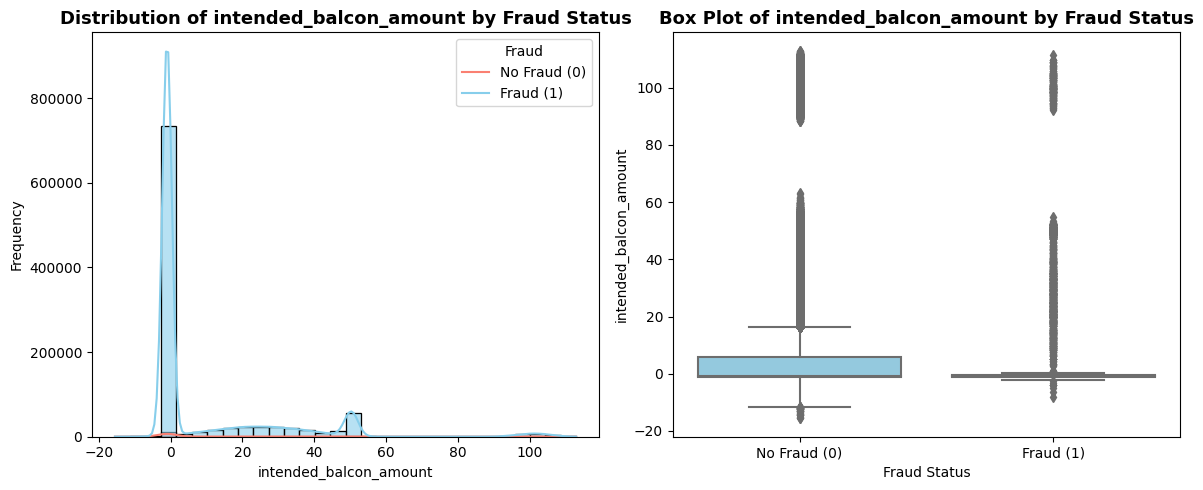

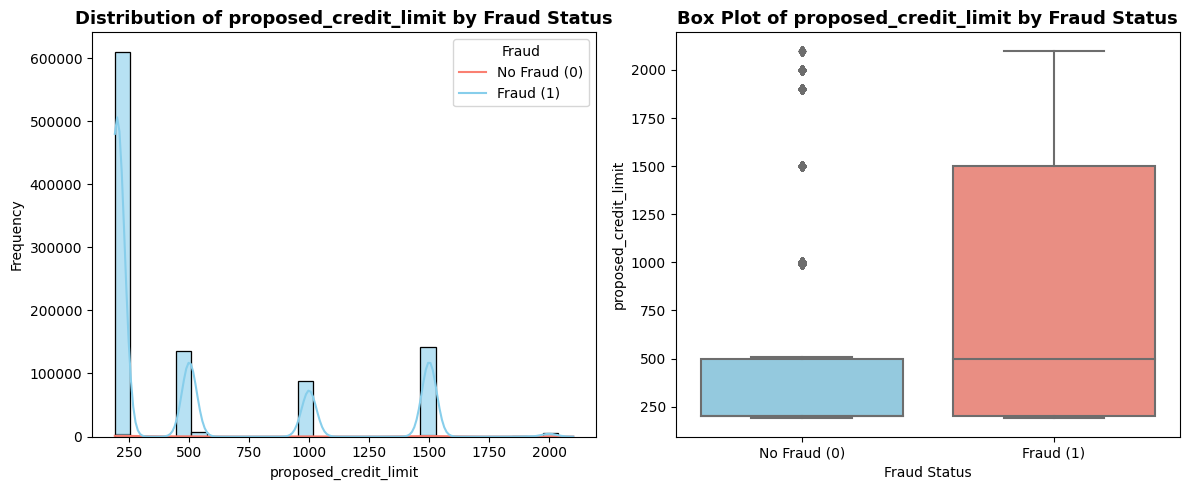

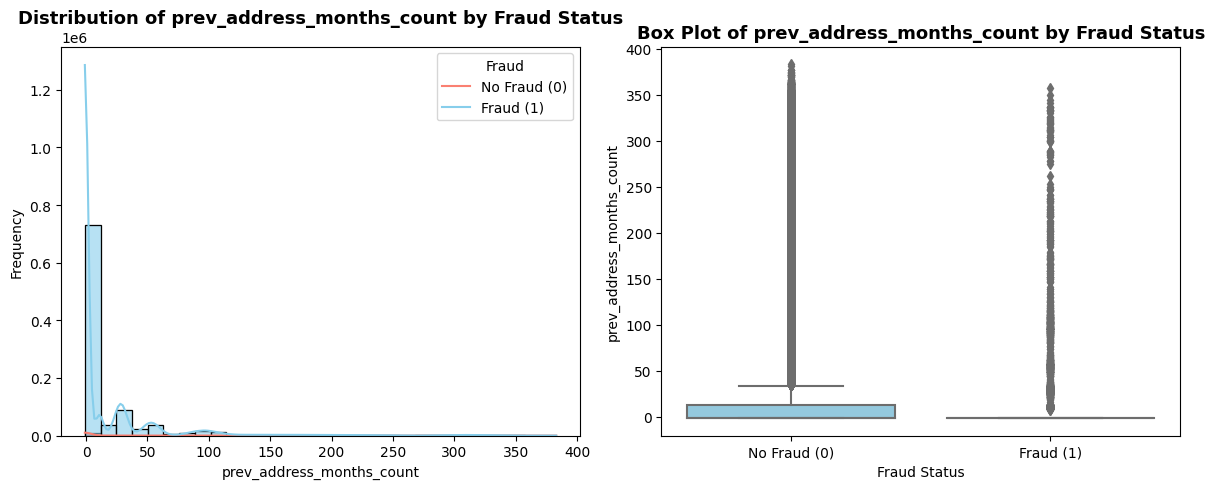

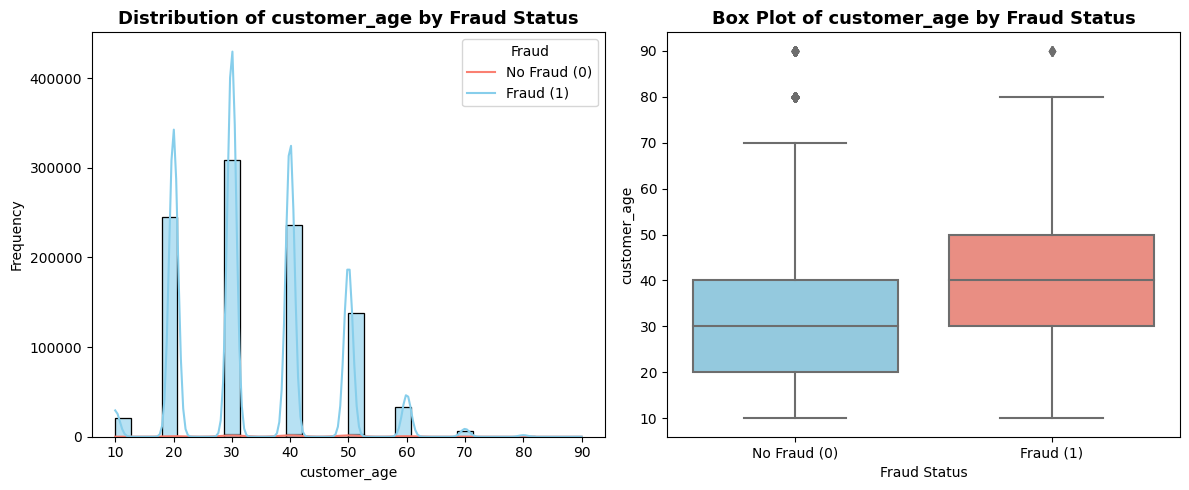

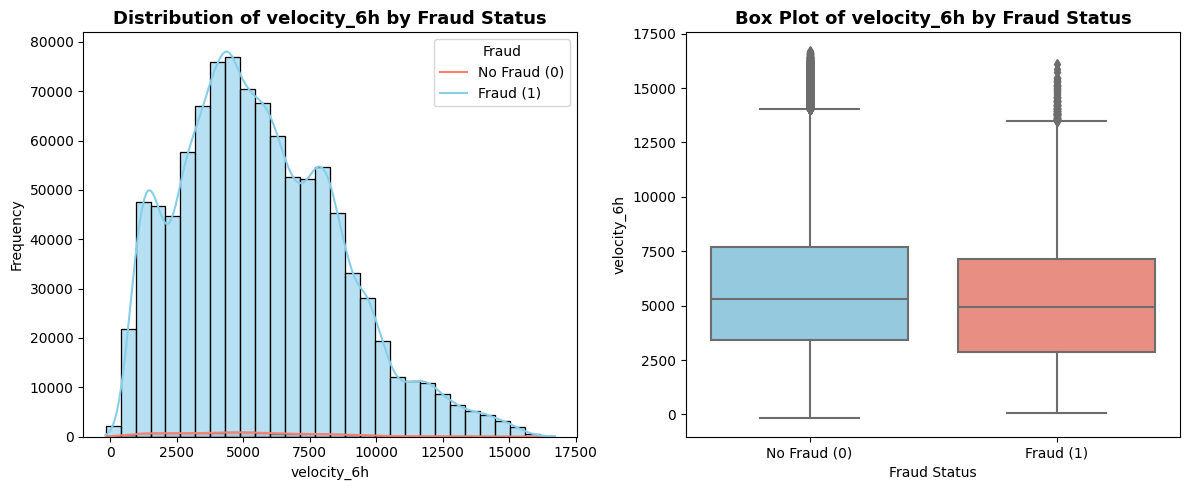

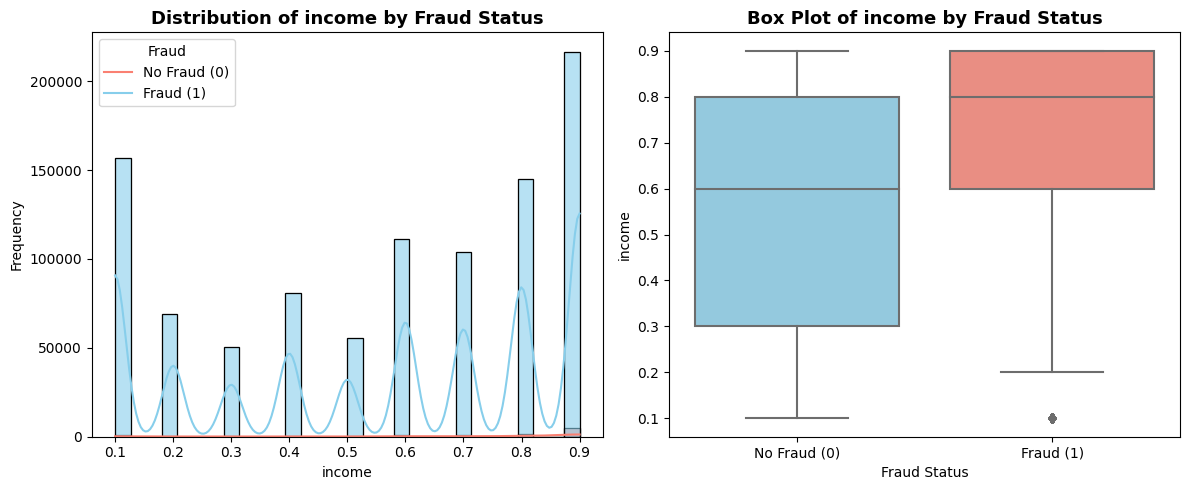

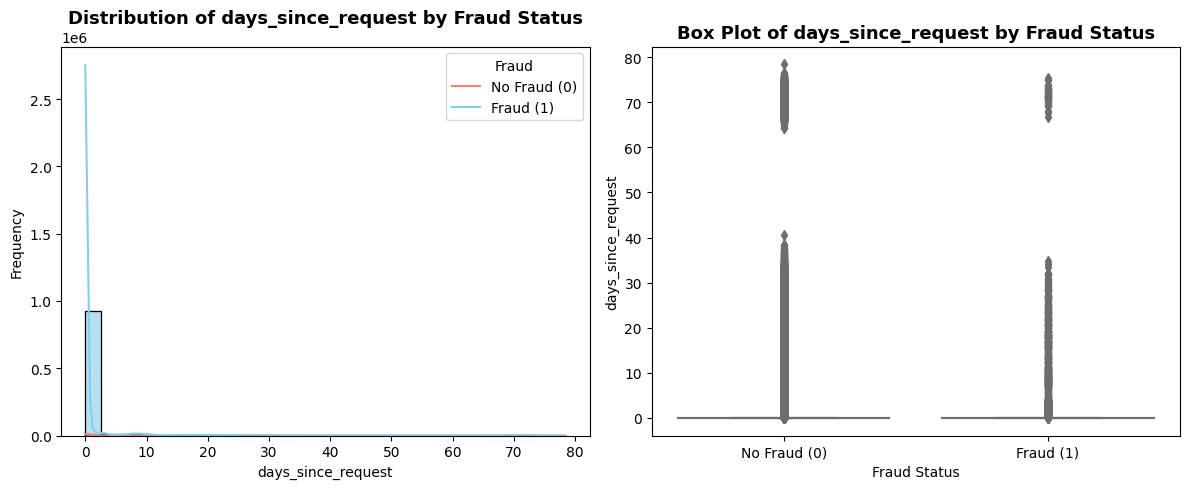

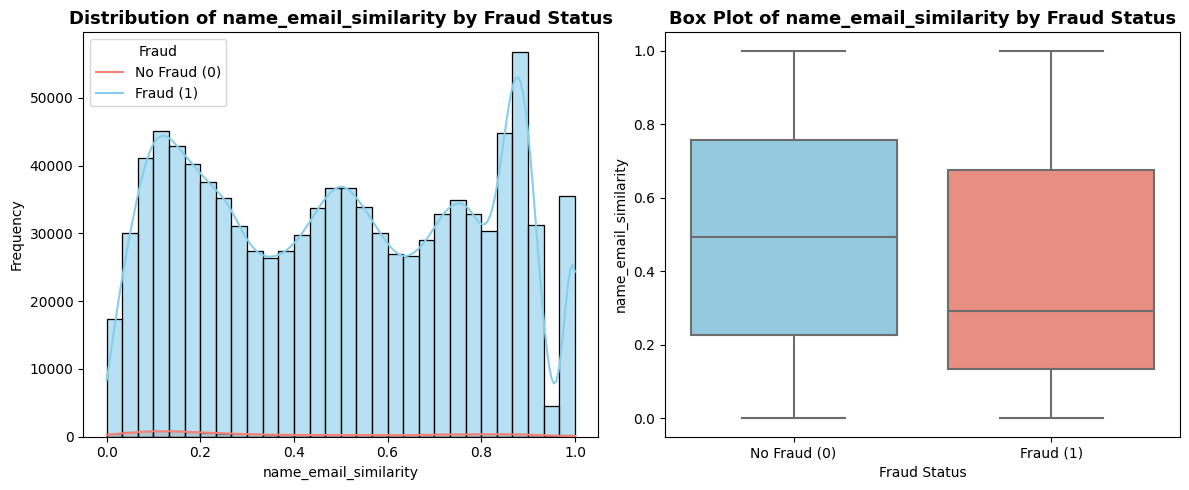

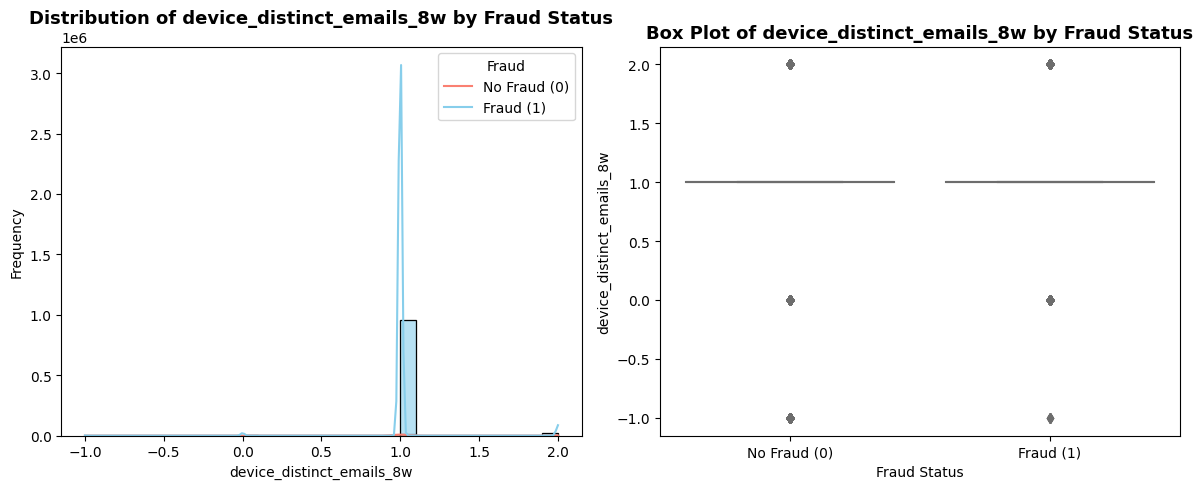

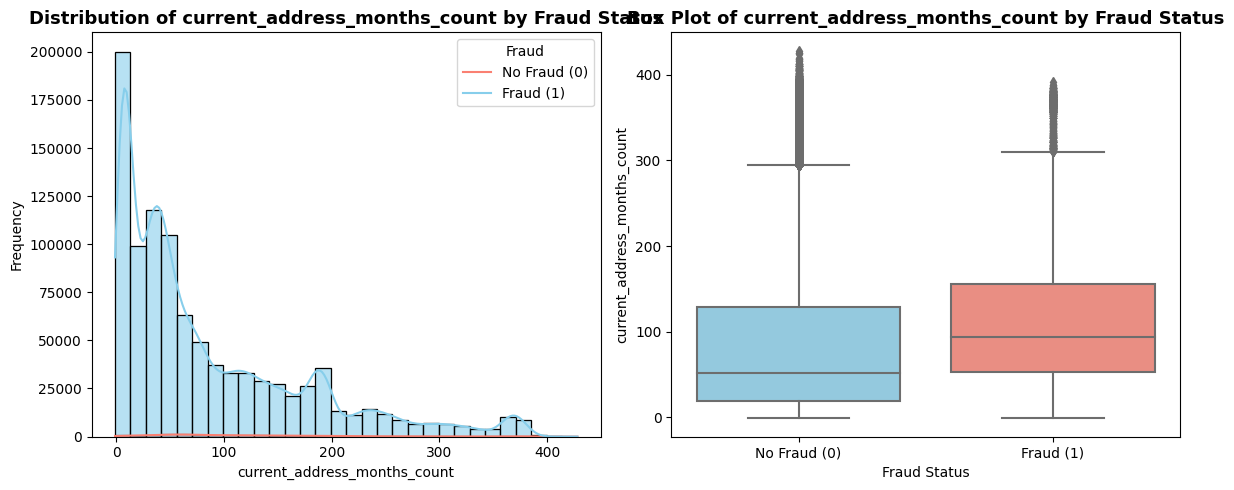

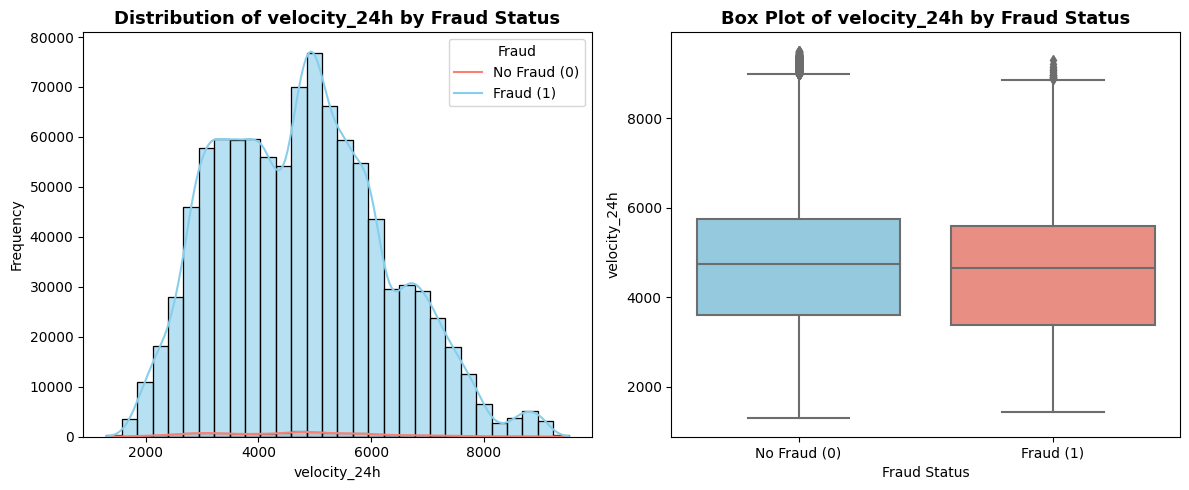

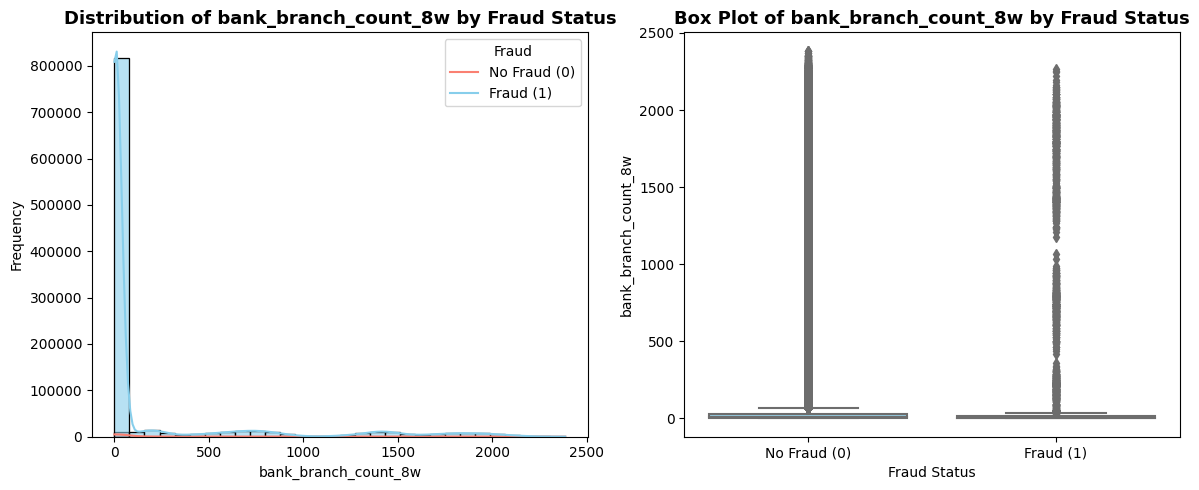

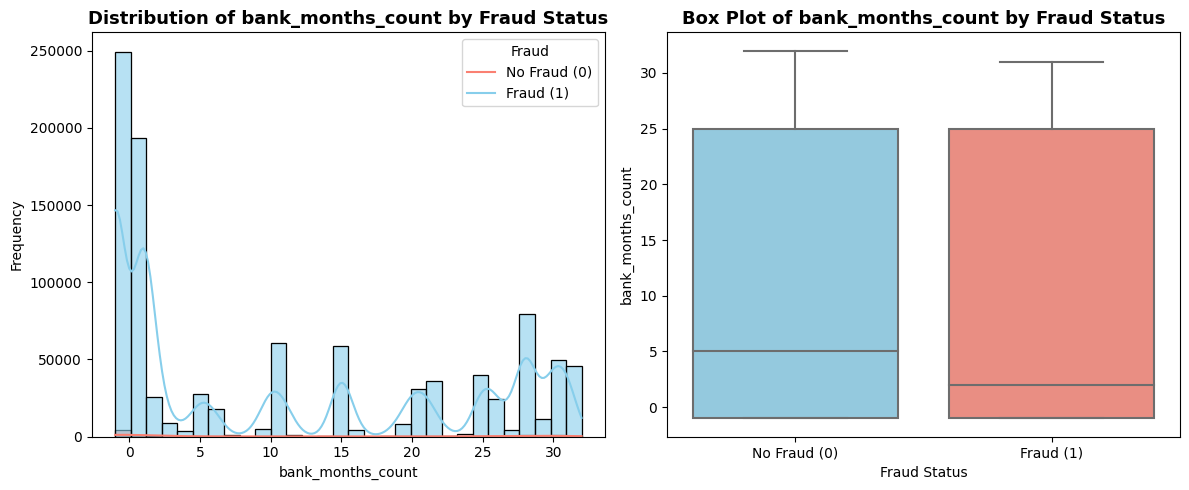

In [17]:
target_col = 'fraud_bool'

for col in numerical_columns:
    plt.figure(figsize=(12, 5))

    kde_flag = base_version[col].nunique() > 1

    plt.subplot(1, 2, 1)
    sns.histplot(
        data=base_version,
        x=col,
        hue=target_col,
        bins=30,
        kde=kde_flag,
        palette=['skyblue', 'salmon'],
        alpha=0.6
    )
    plt.title(f'Distribution of {col} by Fraud Status', fontsize=13, weight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend(title='Fraud', labels=['No Fraud (0)', 'Fraud (1)'])

    plt.subplot(1, 2, 2)
    sns.boxplot(
        data=base_version,
        x=target_col,
        y=col,
        palette=['skyblue', 'salmon']
    )
    plt.title(f'Box Plot of {col} by Fraud Status', fontsize=13, weight='bold')
    plt.xlabel('Fraud Status')
    plt.ylabel(col)
    plt.xticks([0, 1], ['No Fraud (0)', 'Fraud (1)'])

    plt.tight_layout()
    plt.show()


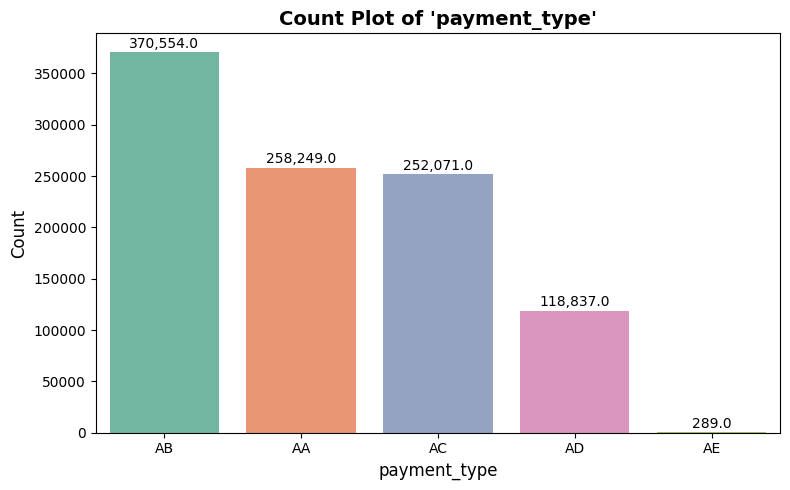

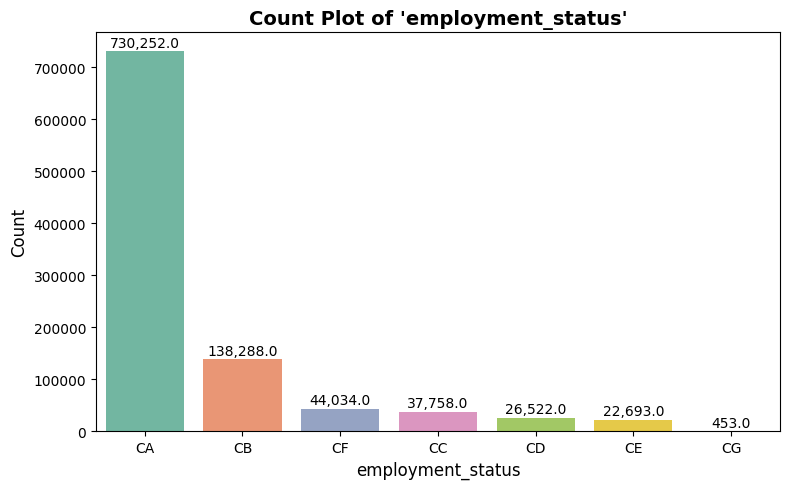

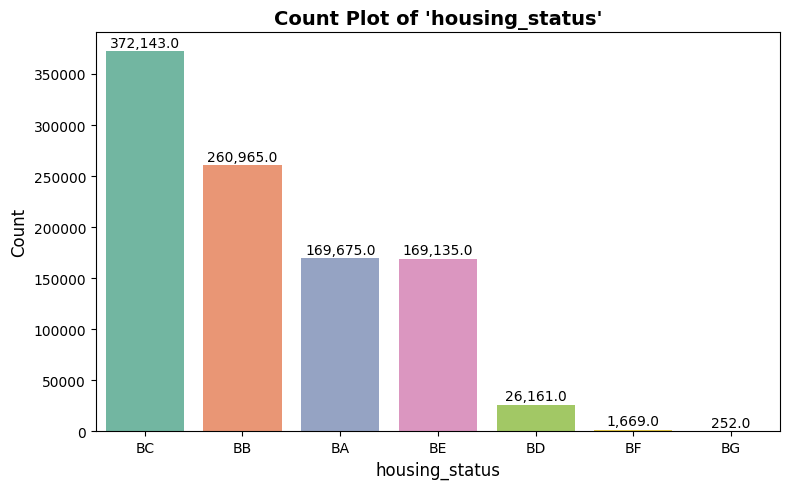

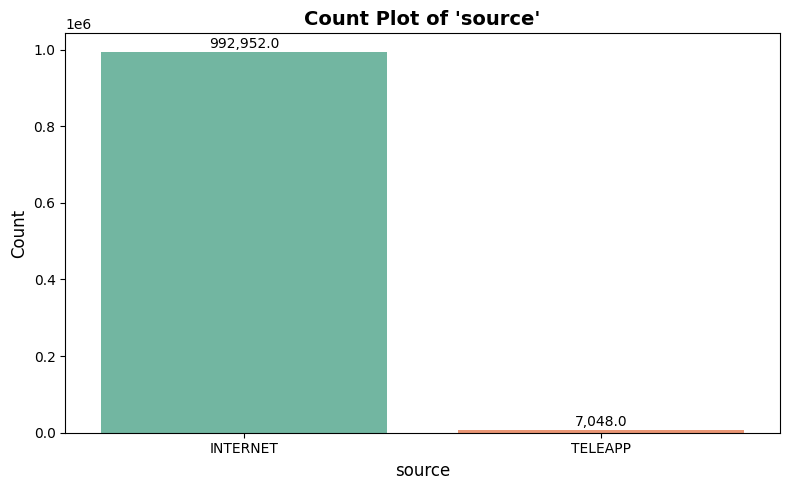

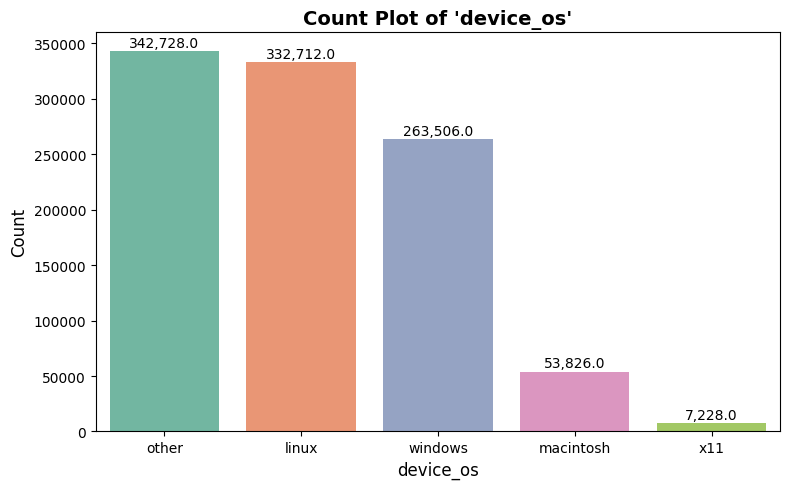

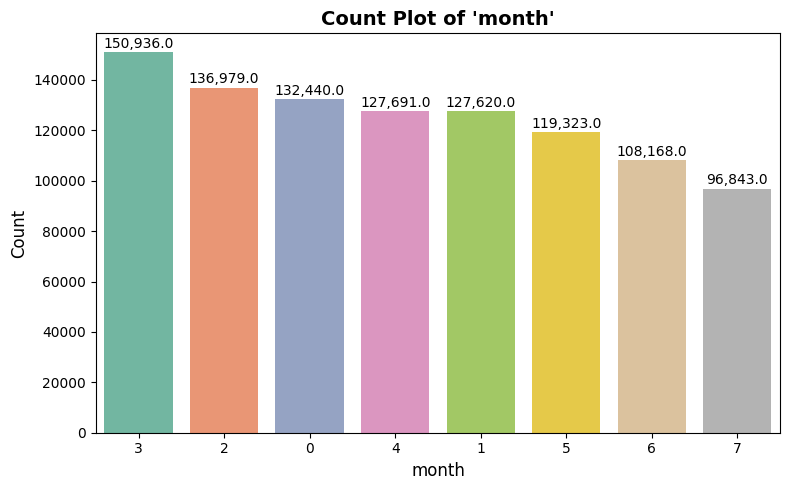

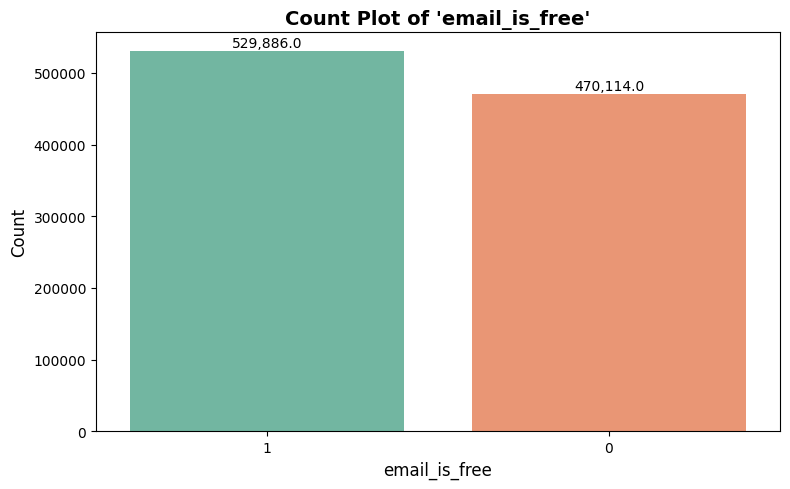

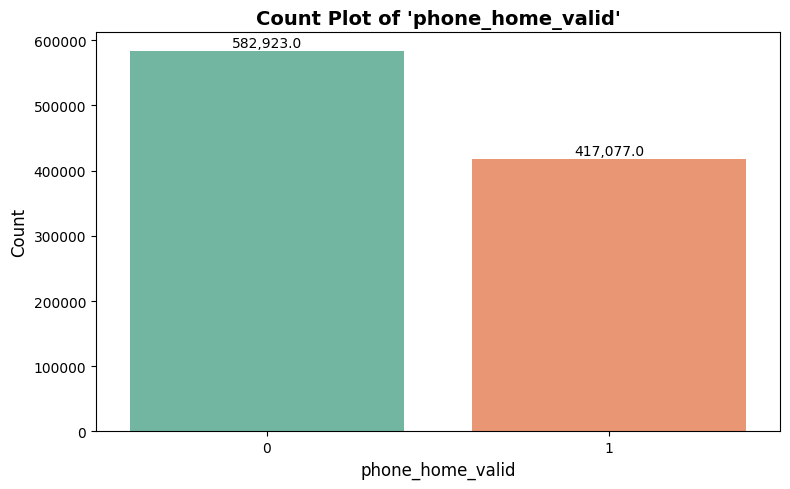

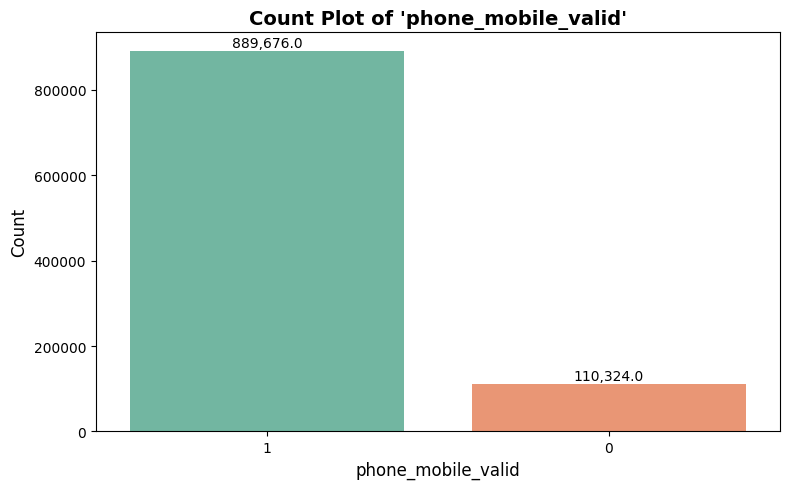

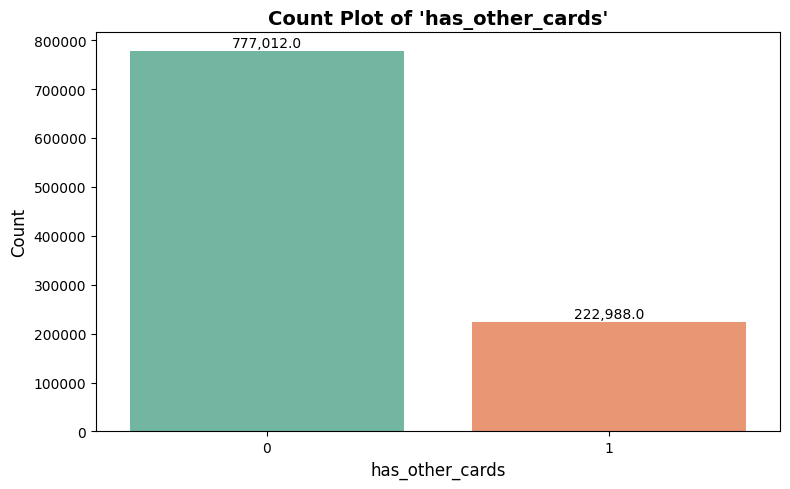

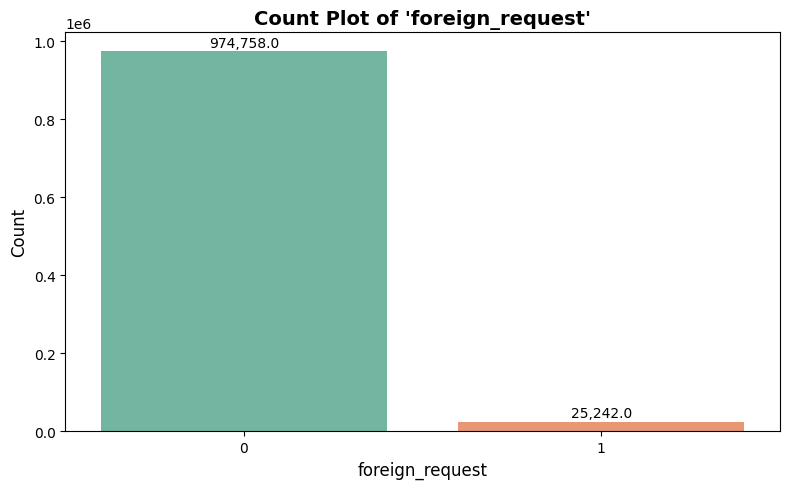

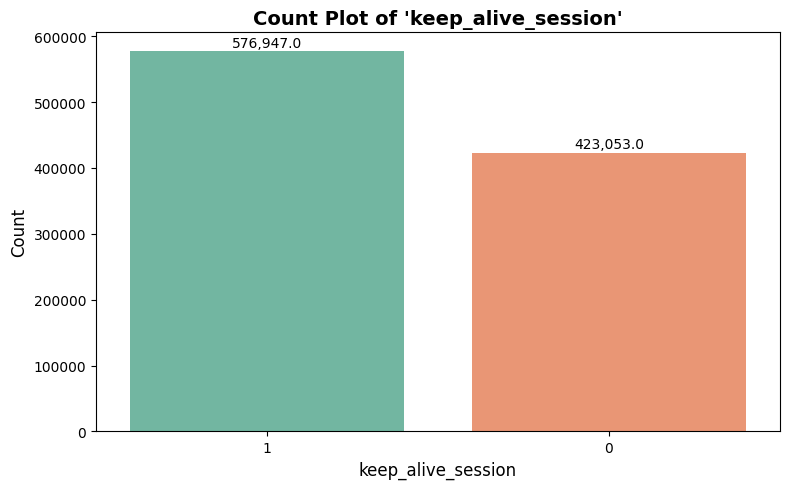

In [18]:
cols_to_plot = categorical_columns + binary_columns

for col in cols_to_plot:
    plt.figure(figsize=(8, 5))

    order = base_version[col].value_counts().index

    ax = sns.countplot(data=base_version, x=col, order=order, palette="Set2")

    for p in ax.patches:
        ax.annotate(f'{p.get_height():,}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 6),
                    textcoords='offset points')

    # Styling
    plt.title(f"Count Plot of '{col}'", fontsize=14, weight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xticks()
    plt.tight_layout()
    plt.show()

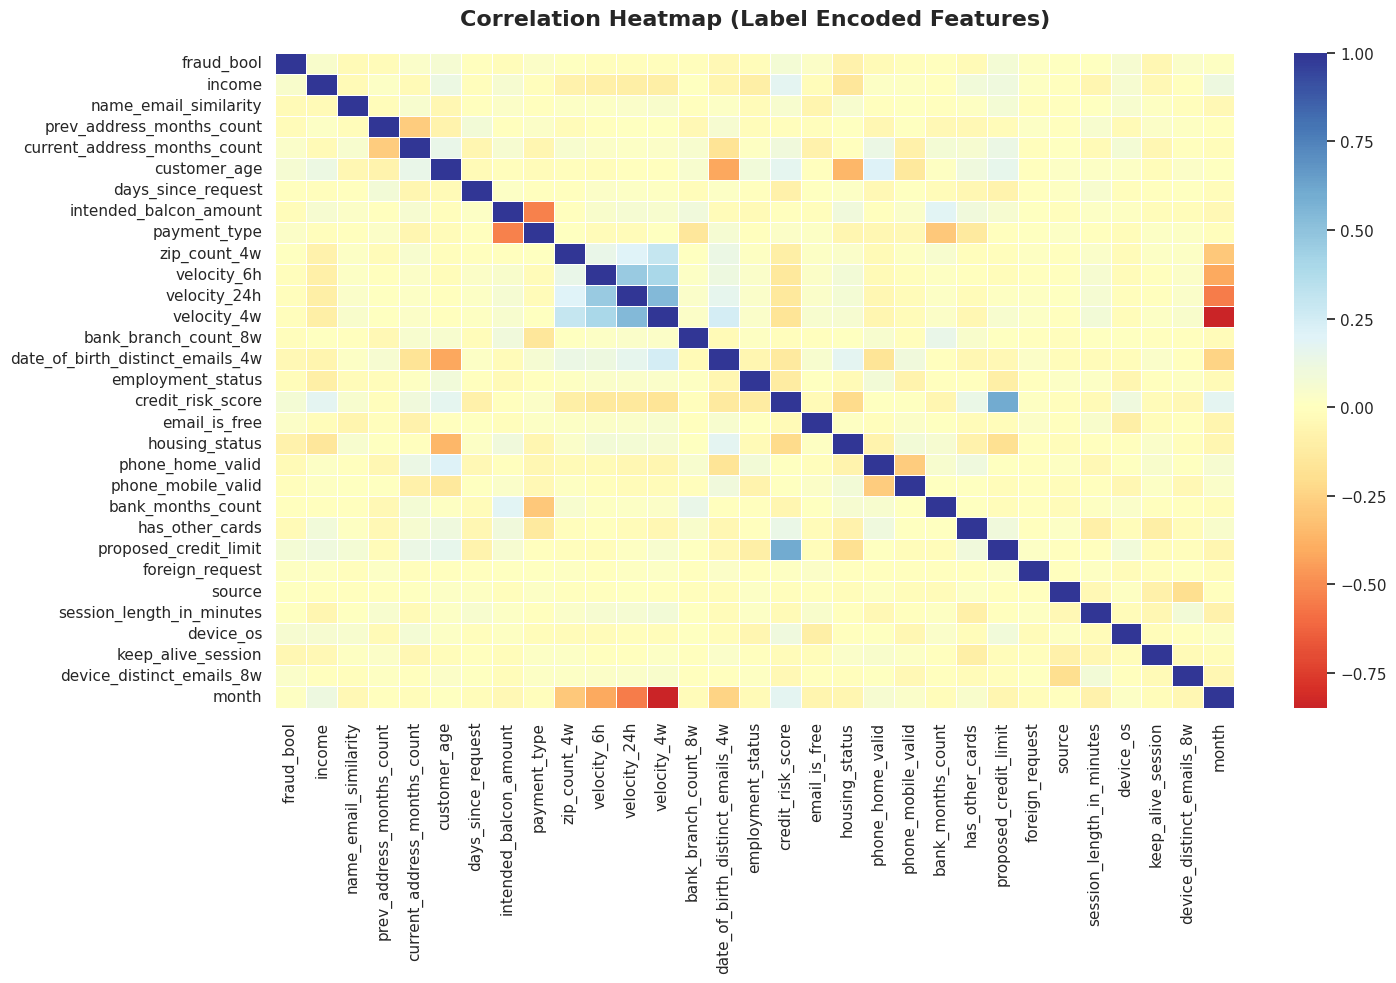

In [19]:
df_encoded = base_version.copy()

le = LabelEncoder()

for col in categorical_columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

corr_matrix = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(15, 10))
sns.set_theme(style="white")

sns.heatmap(
    corr_matrix,
    cmap="RdYlBu",
    annot=False,
    fmt=".2f",
    linewidths=0.5,
    center=0
)

plt.title("Correlation Heatmap (Label Encoded Features)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# Missing Values handling

In [20]:
missing = [
    "prev_address_months_count",
    "bank_months_count",
    "current_address_months_count",
    "session_length_in_minutes",
    "credit_risk_score",
    "device_distinct_emails_8w"
]


In [21]:
#convert -1 to NAN
for col in missing:
    base_version[col] = base_version[col].replace(-1, np.nan)

In [22]:
#missing values flags
for col in missing:
    base_version[f"{col}_flag"] = base_version[col].isna().astype(int)

In [23]:
high_missing_cols = [
    "prev_address_months_count",
    "bank_months_count"
]

bayes_cols = [
    "current_address_months_count",
    "session_length_in_minutes",
    "credit_risk_score",
    "device_distinct_emails_8w"
]

# imputation techniques

**Iterative + BayesianRidge**

In [24]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

beyesImp = base_version.copy()

df_subset_bayes = beyesImp.sample(50000, random_state=42)

bayes_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=15,
    random_state=42
)

bayes_imputer.fit(df_subset_bayes[bayes_cols])

beyesImp[bayes_cols] = bayes_imputer.transform(beyesImp[bayes_cols])

**distribution-preserving imputation**

In [25]:
for col in high_missing_cols:
    mask = beyesImp[col].isna()
    observed_values = beyesImp.loc[~mask, col].values
    beyesImp.loc[mask, col] = np.random.choice(
        observed_values,
        size=mask.sum(),
        replace=True
    )


In [26]:
beyesImp[missing].isna().sum()

prev_address_months_count       0
bank_months_count               0
current_address_months_count    0
session_length_in_minutes       0
credit_risk_score               0
device_distinct_emails_8w       0
dtype: int64

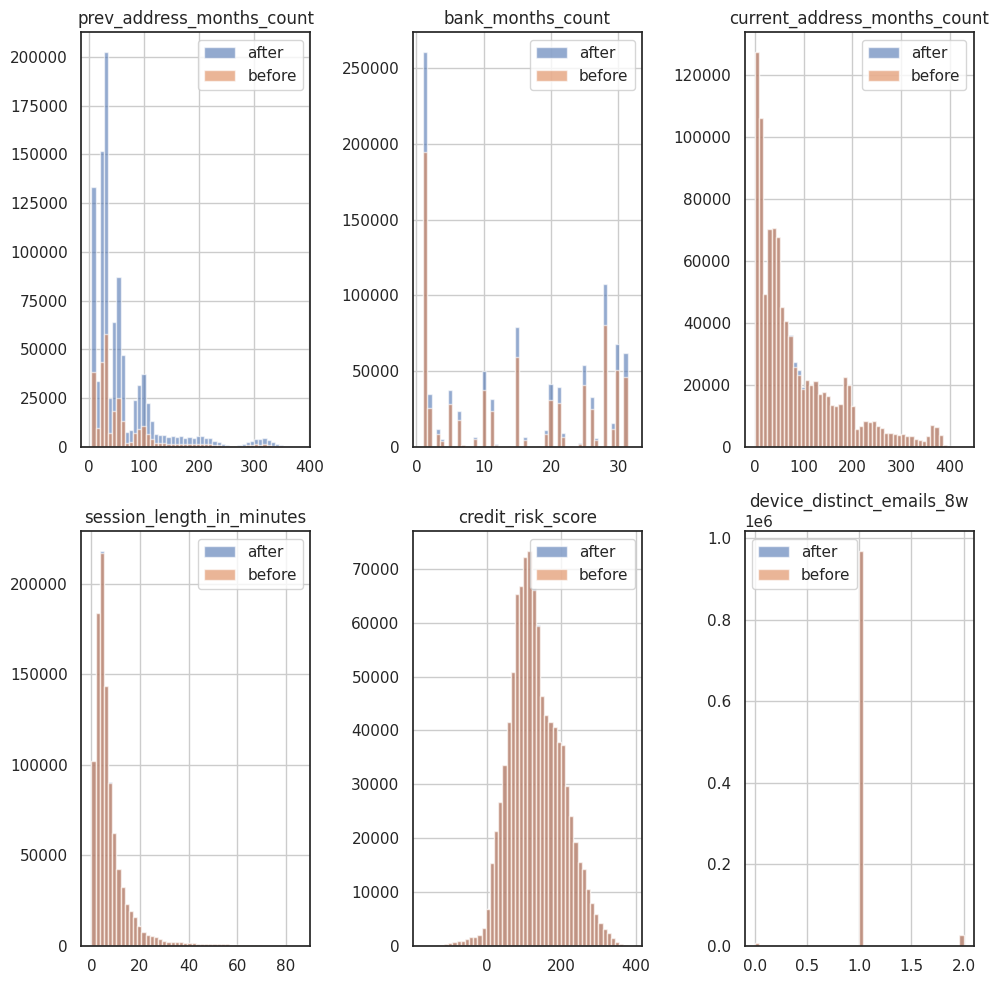

In [27]:
#Distribution comparison
fig, axes = plt.subplots(2, 3, figsize=(10, 10))
axes = axes.flatten()

for i, col in enumerate(missing):
    ax = axes[i]
    beyesImp[col].hist(bins=50, alpha=0.6, label="after", ax=ax)
    base_version[col].dropna().hist(bins=50, alpha=0.6, label="before", ax=ax)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()


In [28]:
#Correlation stability
corr_before = base_version[missing].corr()
corr_after = beyesImp[missing].corr()
abs(corr_after - corr_before)


,prev_address_months_count,bank_months_count,current_address_months_count,session_length_in_minutes,credit_risk_score,device_distinct_emails_8w
prev_address_months_count,0.000000,0.017769,0.108840,0.003801,0.017834,0.010588
bank_months_count,0.017769,0.000000,0.014274,0.009453,0.018691,0.003953
current_address_months_count,0.108840,0.014274,0.000000,0.000102,0.000132,0.000018
session_length_in_minutes,0.003801,0.009453,0.000102,0.000000,0.000078,0.001450
credit_risk_score,0.017834,0.018691,0.000132,0.000078,0.000000,0.000020
device_distinct_emails_8w,0.010588,0.003953,0.000018,0.001450,0.000020,0.000000


In [29]:
for col in missing:
    print(col, ":")
    print(beyesImp.groupby(f"{col}_flag")["fraud_bool"].mean(), "\n")


prev_address_months_count :
prev_address_months_count_flag
0    0.003118
1    0.014215
Name: fraud_bool, dtype: float64 

bank_months_count :
bank_months_count_flag
0    0.009230
1    0.016323
Name: fraud_bool, dtype: float64 

current_address_months_count :
current_address_months_count_flag
0    0.011062
1    0.003291
Name: fraud_bool, dtype: float64 

session_length_in_minutes :
session_length_in_minutes_flag
0    0.011033
1    0.008933
Name: fraud_bool, dtype: float64 

credit_risk_score :
credit_risk_score_flag
0    0.011034
1    0.000000
Name: fraud_bool, dtype: float64 

device_distinct_emails_8w :
device_distinct_emails_8w_flag
0    0.011029
1    0.011142
Name: fraud_bool, dtype: float64 



**Iterative + ExtraTreesRegressor (Tree-based)**


In [30]:
from sklearn.ensemble import ExtraTreesRegressor

treeImp = base_version.copy()

df_subset_tree = treeImp.sample(50000, random_state=42)

imputer_tree = IterativeImputer(
    estimator=ExtraTreesRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    ),
    max_iter=10,
    random_state=42
)

imputer_tree.fit(df_subset_tree[missing])

treeImp[missing] = imputer_tree.transform(treeImp[missing])

In [31]:
treeImp[missing].isna().sum()

prev_address_months_count       0
bank_months_count               0
current_address_months_count    0
session_length_in_minutes       0
credit_risk_score               0
device_distinct_emails_8w       0
dtype: int64

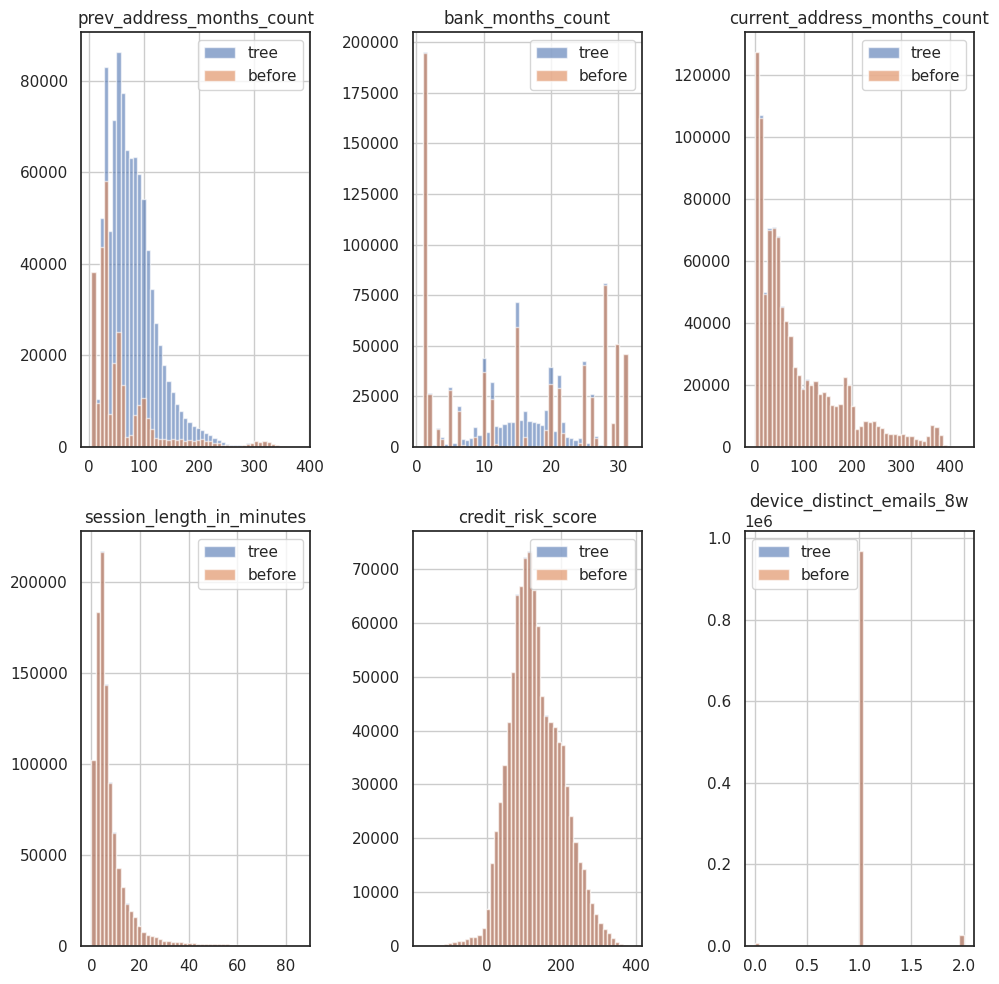

In [32]:
#Distribution comparison
fig, axes = plt.subplots(2, 3, figsize=(10, 10))
axes = axes.flatten()

for i, col in enumerate(missing):
    ax = axes[i]
    treeImp[col].hist(bins=50, alpha=0.6, label="tree", ax=ax)
    base_version[col].dropna().hist(bins=50, alpha=0.6, label="before", ax=ax)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

In [33]:
#Correlation stability
corr_before = base_version[missing].corr()
corr_after_tree = treeImp[missing].corr()

abs(corr_after_tree - corr_before)


,prev_address_months_count,bank_months_count,current_address_months_count,session_length_in_minutes,credit_risk_score,device_distinct_emails_8w
prev_address_months_count,0.000000,0.124815,0.148704,0.038919,0.003173,0.008672
bank_months_count,0.124815,0.000000,0.002992,0.004697,0.003921,0.004095
current_address_months_count,0.148704,0.002992,0.000000,0.000189,0.000178,0.000078
session_length_in_minutes,0.038919,0.004697,0.000189,0.000000,0.000088,0.001667
credit_risk_score,0.003173,0.003921,0.000178,0.000088,0.000000,0.000038
device_distinct_emails_8w,0.008672,0.004095,0.000078,0.001667,0.000038,0.000000


In [34]:
#Fraud Signal
for col in missing:
    print(col, ":")
    print(treeImp.groupby(f"{col}_flag")["fraud_bool"].mean(), "\n")

prev_address_months_count :
prev_address_months_count_flag
0    0.003118
1    0.014215
Name: fraud_bool, dtype: float64 

bank_months_count :
bank_months_count_flag
0    0.009230
1    0.016323
Name: fraud_bool, dtype: float64 

current_address_months_count :
current_address_months_count_flag
0    0.011062
1    0.003291
Name: fraud_bool, dtype: float64 

session_length_in_minutes :
session_length_in_minutes_flag
0    0.011033
1    0.008933
Name: fraud_bool, dtype: float64 

credit_risk_score :
credit_risk_score_flag
0    0.011034
1    0.000000
Name: fraud_bool, dtype: float64 

device_distinct_emails_8w :
device_distinct_emails_8w_flag
0    0.011029
1    0.011142
Name: fraud_bool, dtype: float64 

